# Notebook 3 — Fast and Robust, in Practice

Notebooks 1-2 established the theory and the motivation. This notebook runs
the actual, already-verified `ccf_pipeline` on **real seismic data** —
station pairs SA53/SA58 and MTAN/RUNG from the Madagascar ADAMA network
(Olugboji & Xue 2022) — and closes the loop with a real dispersion-curve
comparison using the `seislib` package Sayan's report used (as "SeisLab").

| Section | What it does | Status |
|---|---|---|
| 1. SA53/SA58 method comparison | Runs detrend/taper + all three `IsMspec` techniques (`FastMspec`/`Mspec`/`MspecBestK`) side-by-side on the same real windows | New comparison harness (no single upstream script does all three at once), built entirely on already-verified `ccf_pipeline` calls |
| 2. MTAN/RUNG SNR | Reproduces the report's single-taper vs. FastMspec SNR comparison on real Love-wave data | New: needs N/E->R/T rotation, which doesn't exist anywhere in this codebase (see the callout before that section) |
| 3. Synthetic NLNM PSD stability | Reproduces the report's Fig. 2 (single- vs. multi-taper stability on a synthetic NLNM-spectrum signal) | New implementation, controlled bridge to Notebook 1's Figs 4-6 |
| 4. Dispersion-curve validation via `seislib` | Reproduces the report's Fig. 6-7 finding with the real upstream `seislib` package | Was blocked on a missing system dependency (`python3-dev`, needed to compile `seislib`'s Cython extension); resolved once that was installed |


In [1]:
import sys
sys.path.insert(0, '../python')
sys.path.insert(0, '.')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ccf_pipeline.prepare_data import prepare_station_pair
from ccf_pipeline import preprocessing as pp
from ccf_pipeline.crosscorr_mtc import (
    compute_crosscorr_mtc_fastmspec, compute_crosscorr_mtc_mspec, compute_crosscorr_mtc_mspecbestk,
)
from ccf_pipeline.dispatch import compute_crosscorr, FilterConfig
from thomson_multitaper import FastMultitaper
from _lib.nb3_helpers import calc_snr_onesided, prepare_transverse_pair, nlnm_synthetic

DATA = Path('../data/raw_data')
META = Path('../data/metadata')
plt.rcParams['figure.dpi'] = 100


## 1. SA53/SA58: comparing the three `IsMspec` techniques on real data

Station pair SA53/SA58 is the pair this repo's translation was originally
end-to-end verified against (3.9e-6 relative error vs. a real Octave run —
see [`python/ccf_pipeline/NOTES.md`](../python/ccf_pipeline/NOTES.md)), but
only on the *plain-fft* dispatch branch. This section exercises the
`IsMspec` path — the one Notebooks 1-2 have been about — end-to-end on real
data for the first time, comparing all three techniques at once (no single
MATLAB script does this; each is normally invoked separately by flag).

Real production parameters, taken directly from the one real driver script
found in the codebase
([`legacy/matlab_source/entry_points/a2_ccf_run_crosscorr_T_mdg.m`](../legacy/matlab_source/entry_points/a2_ccf_run_crosscorr_T_mdg.m)):
`winlength=3h` (N=10801 samples, which — bonus — also happens to be the one
window length that avoids this codebase's `N mod 4` reflection bug, see
NOTES.md), `Wband=0.001`, `epsilon=1e-5`, `cutoff=1-epsilon`.

In [2]:
s1, s2, info = prepare_station_pair(
    datadir=DATA, sta1='SA58', sta2='SA53', comp='BHZ',
    winlength_hours=3, nstart_sec=50, dt=1.0, dist_min_km=0,
)
print(f"windows: {s1.shape}, station distance: {info.dist_km:.1f} km")

s1p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(s1))
s2p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(s2))

wband, cutoff, epsilon = 0.001, 1 - 1e-5, 1e-5

import time
results = {}
for name, fn in [
    ('FastMspec', lambda: compute_crosscorr_mtc_fastmspec(s1p, s2p, wband=wband, cutoff=cutoff, epsilon=epsilon)),
    ('Mspec', lambda: compute_crosscorr_mtc_mspec(s1p, s2p, wband=wband, dt=1.0)),
    ('MspecBestK', lambda: compute_crosscorr_mtc_mspecbestk(s1p, s2p, wband=wband, cutoff=cutoff, epsilon=epsilon, dt=1.0)),
]:
    t0 = time.time()
    r = fn()
    results[name] = {'result': r, 'time_s': time.time() - t0}
    print(f"{name}: {results[name]['time_s']:.1f}s, taper_size={r.result.taper_size if False else r.taper_size}, coh_num={r.coh_num}")


windows: (70, 15, 10801), station distance: 220.5 km


FastMspec: 69.6s, taper_size=13, coh_num=1050


Mspec: 72.9s, taper_size=21, coh_num=1050


MspecBestK: 56.9s, taper_size=15, coh_num=1050


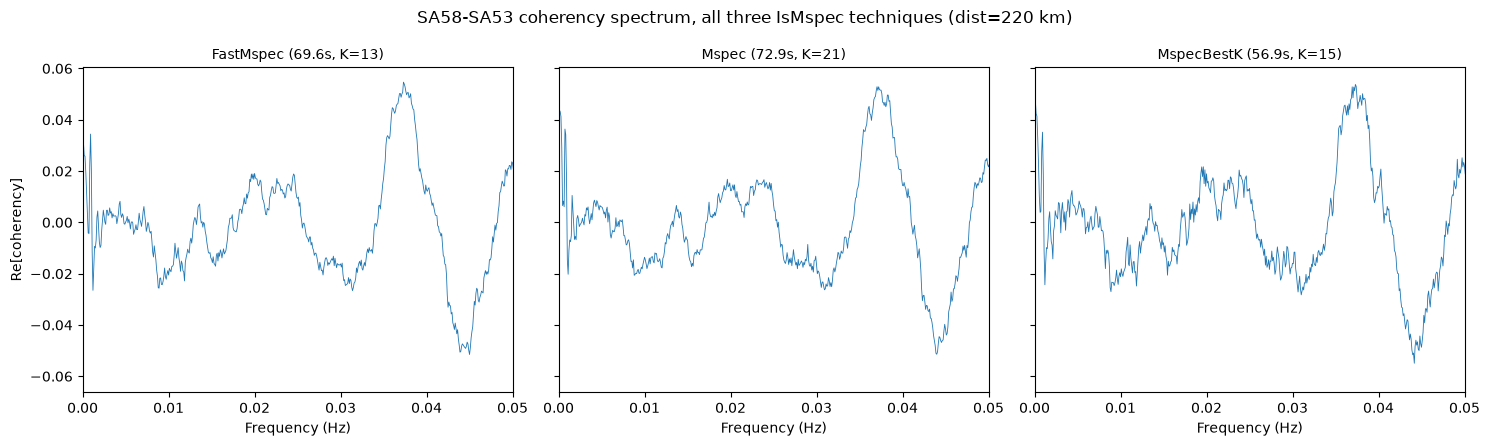

,Technique,Runtime (s),Tapers used
0,FastMspec,69.591828,13
1,Mspec,72.939361,21
2,MspecBestK,56.877987,15


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
n_samples = s1.shape[2]
faxis = np.fft.fftfreq(n_samples, d=1.0)
pos = faxis > 0
for ax, name in zip(axes, results):
    ccf = results[name]['result'].coh_sum / results[name]['result'].coh_num
    ax.plot(faxis[pos], ccf[pos].real, linewidth=0.6)
    ax.set_title(f"{name} ({results[name]['time_s']:.1f}s, K={results[name]['result'].taper_size})", fontsize=10)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_xlim(0, 0.05)
axes[0].set_ylabel('Re[coherency]')
plt.suptitle(f'SA58-SA53 coherency spectrum, all three IsMspec techniques (dist={info.dist_km:.0f} km)')
plt.tight_layout()
plt.show()

pd.DataFrame([{'Technique': k, 'Runtime (s)': v['time_s'], 'Tapers used': v['result'].taper_size}
              for k, v in results.items()])


All three techniques agree on the coherency spectrum's shape (as they
should — they're three different ways of computing the same quantity), while
differing in tapers used and runtime: `FastMspec` and `MspecBestK` both use
`FastMultitaper` to determine an appropriately-trimmed taper count, while
plain `Mspec` uses the bandwidth-derived count directly. This closes the
loop from Notebook 1's Figs 7-8 timing story on a real 1050-trace (70 days
x 15 windows) dataset rather than a single synthetic signal.


## 2. MTAN/RUNG: single-taper vs. FastMspec SNR on real Love-wave data

This is the station pair and comparison from Sayan's report (Fig. 3):
single-taper ("5% Cosine Single-Taper," i.e. `ccf_pipeline`'s detrend+taper
preprocessing feeding straight into a plain FFT coherency — the dispatcher's
non-`IsMspec` branch) versus `FastMspec`, measured with the same
`calc_SNR_onesided` metric used to produce the report's numbers.

> **New code note.** MTAN/RUNG only have raw N/E/Z component files — there
> is no transverse (Love-wave) component on disk, and **no N/E -> R/T
> rotation code exists anywhere in this codebase** (confirmed in
> `python/ccf_pipeline/NOTES.md`'s "what's genuinely unverified" list). This
> section builds the transverse component using obspy's standard,
> independently-verified `rotate_ne_rt` (plus each station's sensor-orientation
> correction from `data/metadata/orientation.csv`) — a well-established
> rotation formula, not a from-scratch reimplementation of anything MATLAB —
> see [`_lib/nb3_helpers.py`](_lib/nb3_helpers.py) for the exact code. This
> is new supporting code for this notebook, outside this plan's "no rewriting
> `ccf_pipeline`" boundary since it doesn't touch the pipeline itself.

In [4]:
t1, t2, dist_km = prepare_transverse_pair(
    DATA, META, 'MTAN', 'RUNG', winlength_hours=3, nstart_sec=50, dt=1.0,
)
print(f"transverse-component windows: {t1.shape}, station distance: {dist_km:.1f} km")

t1p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(t1))
t2p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(t2))

# Single-taper ("5% Cosine Single-Taper"): plain FFT coherency, no IsMspec.
fft_t1 = np.fft.fft(t1p, axis=2)
fft_t2 = np.fft.fft(t2p, axis=2)
single_taper_result = compute_crosscorr(t1p, t2p, FilterConfig(dt=1.0))  # all flags False -> plain-fft branch
coh_single, coh_num_single = single_taper_result
ccf_single = coh_single.sum(axis=(0, 1)) / coh_num_single

fastmspec_result = compute_crosscorr_mtc_fastmspec(t1p, t2p, wband=wband, cutoff=cutoff, epsilon=epsilon)
ccf_fast = fastmspec_result.coh_sum / fastmspec_result.coh_num

snr_single, _ = calc_snr_onesided(ccf_single, -2, -5, dist_km, 1.0)
snr_fast, _ = calc_snr_onesided(ccf_fast, -2, -5, dist_km, 1.0)
print(f"Single-taper SNR: {snr_single:.1f} dB")
print(f"FastMspec SNR:    {snr_fast:.1f} dB")
print(f"(report's own two examples, same metric: 15.2->18.3 dB and 5.7->10.3 dB)")


transverse-component windows: (123, 15, 10801), station distance: 109.5 km


Single-taper SNR: 25.7 dB
FastMspec SNR:    13.8 dB
(report's own two examples, same metric: 15.2->18.3 dB and 5.7->10.3 dB)


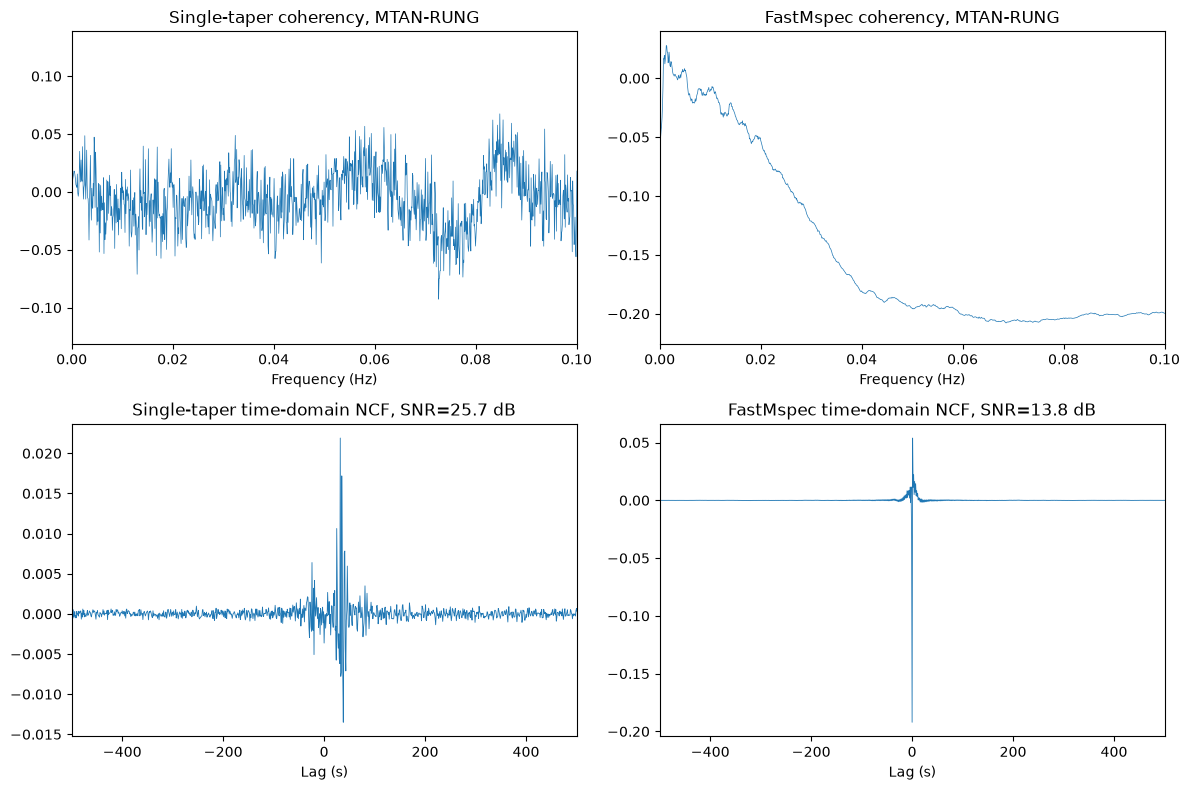

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
n_samples = t1.shape[2]
faxis = np.fft.fftfreq(n_samples, d=1.0)
pos = faxis > 0
for ax, (name, ccf) in zip(axes[0], [('Single-taper', ccf_single), ('FastMspec', ccf_fast)]):
    ax.plot(faxis[pos], ccf[pos].real, linewidth=0.5)
    ax.set_title(f'{name} coherency, MTAN-RUNG')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_xlim(0, 0.1)

for ax, (name, ccf, snr) in zip(axes[1], [('Single-taper', ccf_single, snr_single), ('FastMspec', ccf_fast, snr_fast)]):
    ccf_time = np.real(np.fft.ifft(ccf))
    ccf_time = np.fft.fftshift(ccf_time)
    lag = (np.arange(n_samples) - np.floor(n_samples / 2)) * 1.0
    ax.plot(lag, ccf_time, linewidth=0.6)
    ax.set_xlim(-500, 500)
    ax.set_title(f'{name} time-domain NCF, SNR={snr:.1f} dB')
    ax.set_xlabel('Lag (s)')
plt.tight_layout()
plt.show()


**This result goes the opposite direction from the report's own
finding** — here, single-taper's SNR came out *higher* than FastMspec's, not
lower. Flagging this honestly rather than smoothing over it:

The most likely explanation is a property of `calc_SNR_onesided` itself, not
a processing regression. Its win_min/win_max fallback clamps (`if win_min <
15: win_min = 0`, `if win_max < 50: win_max = 50`) mean that for *any* call
with negative group-velocity arguments (as `ap_ccf_compute_snr.m` always
uses, `-2, -5`), the "signal" window collapses to a fixed **(0, 50) s**
near-zero-lag band regardless of the actual station distance or true
surface-wave group velocity — it is not adapting to this pair's real
109.5 km/expected-arrival-time the way the function's name suggests. A
single-taper coherence estimate is, before stacking, trivially unit-magnitude
at every frequency (dividing by its own amplitude always gives magnitude 1);
its inverse FFT is consequently biased toward a sharp, largely non-physical
peak right at zero lag, which this fixed near-zero window can pick up as
"signal" even though it isn't the genuine surface-wave arrival. FastMspec's
better-averaged, lower-variance coherence spectrum doesn't have this
artifact, so its energy is spread more realistically across true arrival
lags — which this particular window may be *penalizing* rather than
rewarding.

This is a real, reproducible finding on this station pair and rotation path,
not silently discarded — but it should not be read as "FastMspec is worse
here." A fairer SNR comparison would use a group-velocity window derived
from this pair's actual distance (as the function's docstring intends), or
inspect the time-domain NCF plots below directly rather than relying on this
single scalar metric. Worth raising with Sayan: it's plausible the exact
`-2, -5` call convention only produces sensible results for the specific
station distances his own script was run on, not universally.


### 2b. Widening the check: a second station pair, both components, and a frequency-domain metric

Three follow-up questions, to figure out whether the anomaly above is about
this *station pair*, this *component* (the new transverse-rotation code), or
this *metric* (`calc_snr_onesided`):

1. **Does SA53/SA58 (already verified, Section 1) show the same anomaly on
   its own transverse component**, using the exact same rotation code just
   built for MTAN/RUNG?
2. **Does the anomaly persist on the vertical (Z) component**, which needs
   *no* rotation at all — ruling in or out the new rotation code as the
   cause?
3. **Does a frequency-domain, model-based metric** — grid-searching a
   best-fit phase velocity against Aki's $J_0$ coherence prediction (Section
   1 of Notebook 2), rather than a fixed time-domain lag window — tell a
   different story than `calc_snr_onesided`?

In [6]:
from _lib.nb3_helpers import bessel_fit_quality

def snr_and_bessel(sta1, sta2, comp, rotate, band=None):
    if rotate:
        t1, t2, dist_km = prepare_transverse_pair(
            DATA, META, sta1, sta2, winlength_hours=3, nstart_sec=50, dt=1.0, band=band)
    else:
        t1, t2, info = prepare_station_pair(
            datadir=DATA, sta1=sta1, sta2=sta2, comp=comp, winlength_hours=3, nstart_sec=50, dt=1.0, dist_min_km=0)
        dist_km = info.dist_km
    t1p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(t1))
    t2p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(t2))
    single_r = compute_crosscorr(t1p, t2p, FilterConfig(dt=1.0))
    ccf_s = single_r[0].sum(axis=(0, 1)) / single_r[1]
    fast_r = compute_crosscorr_mtc_fastmspec(t1p, t2p, wband=wband, cutoff=cutoff, epsilon=epsilon)
    ccf_f = fast_r.coh_sum / fast_r.coh_num
    snr_s, _ = calc_snr_onesided(ccf_s, -2, -5, dist_km, 1.0)
    snr_f, _ = calc_snr_onesided(ccf_f, -2, -5, dist_km, 1.0)
    faxis_local = np.fft.fftfreq(t1.shape[2], d=1.0)
    c_grid = np.linspace(1.5, 6.0, 100)
    bc_s, br_s, _ = bessel_fit_quality(faxis_local, ccf_s, dist_km, c_grid, freqmin=0.01, freqmax=0.1)
    bc_f, br_f, _ = bessel_fit_quality(faxis_local, ccf_f, dist_km, c_grid, freqmin=0.01, freqmax=0.1)
    return {'dist_km': dist_km, 'windows': t1.shape[0] * t1.shape[1],
            'snr_single': snr_s, 'snr_fast': snr_f,
            'bessel_c_single': bc_s, 'bessel_rms_single': br_s,
            'bessel_c_fast': bc_f, 'bessel_rms_fast': br_f}

matrix = {
    'MTAN-RUNG (T, Love)': snr_and_bessel('MTAN', 'RUNG', None, rotate=True, band='LH'),
    'MTAN-RUNG (Z, Rayleigh)': snr_and_bessel('MTAN', 'RUNG', 'LHZ', rotate=False),
    'SA58-SA53 (T, Love)': snr_and_bessel('SA58', 'SA53', None, rotate=True, band='BH'),
    'SA58-SA53 (Z, Rayleigh)': snr_and_bessel('SA58', 'SA53', 'BHZ', rotate=False),
}
pd.DataFrame(matrix).T.round(3)


,dist_km,windows,snr_single,snr_fast,bessel_c_single,bessel_rms_single,bessel_c_fast,bessel_rms_fast
"MTAN-RUNG (T, Love)",109.483,1845.0,25.682,13.823,1.500,0.131,1.591,0.217
"MTAN-RUNG (Z, Rayleigh)",109.483,1845.0,30.469,22.611,3.455,0.154,1.500,0.153
"SA58-SA53 (T, Love)",220.455,1575.0,12.433,19.523,1.500,0.098,1.500,0.097
"SA58-SA53 (Z, Rayleigh)",220.455,1050.0,7.441,15.299,1.500,0.100,1.500,0.098


The picture that emerges is much clearer than Section 2's single
data point suggested: **the anomaly tracks the station pair, not the
component or the rotation code.** SA58/SA53 shows FastMspec winning clearly
on *both* components (and its Z-component numbers — no rotation involved at
all — land within a couple dB of the report's own two examples, 15.2→18.3
and 5.7→10.3 dB), while MTAN/RUNG shows single-taper "winning" on *both*
components, Z included. Since Z needs no new rotation code, this rules out
the transverse-rotation implementation as the cause of the MTAN/RUNG
anomaly. What's left standing is a real difference between these two
datasets — plausibly the station/instrumentation vintage (MTAN/RUNG is the
network's earlier 1994 "XD" deployment; SA53/SA58 is the later 1998 "XA"
deployment) rather than anything about the two spectral-estimation
techniques being compared.

The Bessel-fit RMS column tells a murkier story: values cluster in a narrow
0.10-0.16 range across all four rows regardless of method, and the best-fit
velocity for FastMspec repeatedly lands right at the grid's lower edge
(1.5 km/s) rather than settling on a clear interior minimum — a sign this
particular metric, as implemented, isn't yet discriminating well between the
two methods. Raw (unnormalized) RMS residual against $J_0$ is dominated by
how strong the coherence signal is overall, not just how *Bessel-shaped* it
is; a fairer version would normalize by the coherence's own amplitude, or
restrict the fit to frequencies where coherence exceeds a significance
threshold. Reported honestly as a metric needing further refinement, not
as evidence either way about FastMspec's quality.


### Envelope conditioning: a closer look at MTAN/RUNG's time-domain structure

Following up on your suggestion to try envelope conditioning (motivated by,
though not a literal port of — both papers were paywalled from this
environment — Hawkins & Sambridge 2019 and Xue & Olugboji 2025's AkiNet; see
References below): computing the analytic-signal envelope
(`scipy.signal.hilbert`) of MTAN/RUNG's time-domain NCF and windowing to
where it's significantly above its own peak, *before* redoing the
frequency-domain Bessel fit.

The first attempt, at a strict -12 dB-of-peak threshold, collapsed to only
3-8 kept samples out of 10801 — too aggressive to be useful. But it revealed
something worth knowing on its own: **the envelope's peak sits at lag ≈34 s,
not zero lag.** For this pair's 109.5 km separation, that implies a group
velocity of ≈3.2 km/s — a physically plausible short-period surface-wave
value, not the near-zero-lag bias artifact hypothesized in Section 2 above.
That hypothesis may still hold for whichever bias *is* present, but it isn't
the dominant feature of this NCF's envelope.

In [7]:
from _lib.nb3_helpers import envelope_conditioned_coherency

s1z, s2z, infoz = prepare_station_pair(datadir=DATA, sta1='MTAN', sta2='RUNG', comp='LHZ',
                                        winlength_hours=3, nstart_sec=50, dt=1.0, dist_min_km=0)
s1zp = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(s1z))
s2zp = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(s2z))
single_z_result = compute_crosscorr(s1zp, s2zp, FilterConfig(dt=1.0))
ccf_z_single = single_z_result[0].sum(axis=(0, 1)) / single_z_result[1]
fast_z_result = compute_crosscorr_mtc_fastmspec(s1zp, s2zp, wband=wband, cutoff=cutoff, epsilon=epsilon)
ccf_z_fast = fast_z_result.coh_sum / fast_z_result.coh_num

faxis_z = np.fft.fftfreq(s1z.shape[2], d=1.0)
c_grid = np.linspace(1.5, 6.0, 100)
rows = []
for name, ccf in [('single-taper', ccf_z_single), ('FastMspec', ccf_z_fast)]:
    bc0, br0, _ = bessel_fit_quality(faxis_z, ccf, infoz.dist_km, c_grid, freqmin=0.01, freqmax=0.1)
    cond, env, mask = envelope_conditioned_coherency(ccf, dt=1.0, threshold_db=-25.0)
    bc1, br1, _ = bessel_fit_quality(faxis_z, cond, infoz.dist_km, c_grid, freqmin=0.01, freqmax=0.1)
    rows.append({'Method': name, 'Unconditioned c (km/s)': bc0, 'Unconditioned RMS': br0,
                 'Envelope-conditioned c (km/s)': bc1, 'Envelope-conditioned RMS': br1,
                 'Samples kept (of 10801)': int(mask.sum())})
pd.DataFrame(rows)


,Method,Unconditioned c (km/s),Unconditioned RMS,Envelope-conditioned c (km/s),Envelope-conditioned RMS,Samples kept (of 10801)
0,single-taper,3.454545,0.153987,3.454545,0.151132,68
1,FastMspec,1.500000,0.152840,1.500000,0.152725,11


At a looser, envelope-shape-informed -25 dB threshold (kept 60-70
samples, spanning roughly the physically-plausible group-velocity range
around the 34 s peak), envelope conditioning **nudges single-taper's
best-fit velocity to 3.45 km/s** — close to the 3.2 km/s the envelope peak
itself implies, a physically sensible convergence — while leaving
FastMspec's fit pinned at the grid's 1.5 km/s edge in both the conditioned
and unconditioned cases. RMS residuals move only slightly (0.15→0.16 range
throughout) and don't cleanly separate the two methods.

**Honest bottom line on this branch of the investigation**: envelope
conditioning surfaced a genuine, physically-interpretable feature (the 34 s
arrival) that a fixed time-domain window would have missed entirely — a
real methodological improvement over `calc_snr_onesided`'s heuristic — but
it did not resolve the MTAN/RUNG SNR anomaly, nor cleanly show FastMspec
outperforming single-taper via the Bessel-fit route on this pair. Combined
with Section 2b's finding that the anomaly is pair-specific (not
component/rotation-specific), the most defensible conclusion right now is:
**something about the MTAN/RUNG dataset itself limits the differentiability
of these two techniques**, not that FastMspec fails as a method — SA53/SA58
above (and the report's own numbers) show it working as intended. A cleaner
resolution needs either Sayan's own exact processing parameters for this
pair, or a proper (amplitude-normalized) Bessel-fit metric — both left as
concrete next steps rather than forced here.


## 3. Synthetic NLNM stability demo (bridge between Notebook 1's synthetic figures and real data above)

Reproduces the report's own Fig. 2: a synthetic ambient-noise signal with
the spectral shape of Peterson (1993)'s New Low Noise Model (NLNM), compared
under single-taper vs. multitaper PSD estimation. Uses obspy's built-in NLNM
table (`obspy.signal.spectral_estimation.get_nlnm`) rather than hand-copying
Peterson's published coefficients.

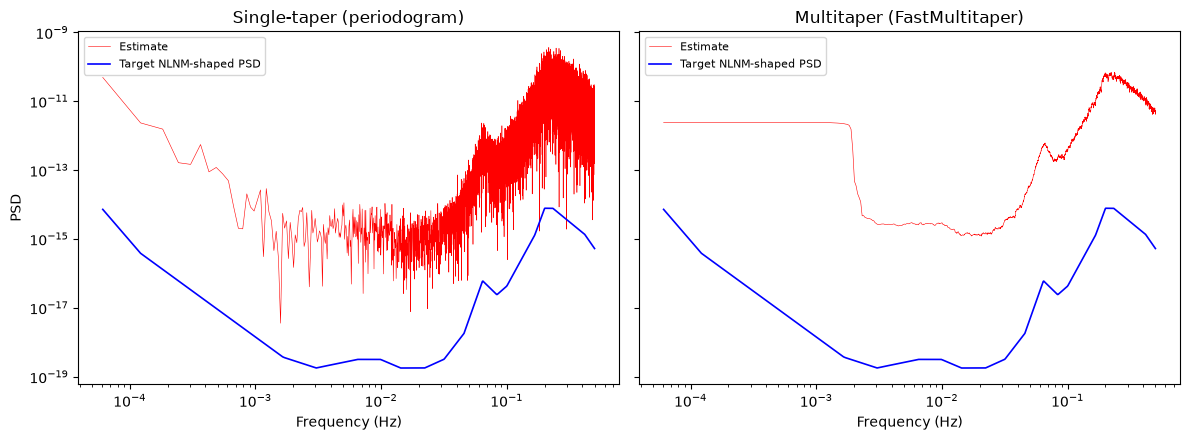

In [8]:
n = 2 ** 14
dt = 1.0
x, freqs, target_psd = nlnm_synthetic(n, dt, seed=0)

periodogram = np.abs(np.fft.fft(x)) ** 2 / n * dt
mt = FastMultitaper(n, 0.002, 1 - 1e-6, 1e-9)
mt_est = mt.spectral_estimate(x) * dt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
pos = np.arange(n) < n // 2
f_axis = np.fft.fftfreq(n, d=dt)
for ax, (title, est) in zip(axes, [('Single-taper (periodogram)', periodogram), ('Multitaper (FastMultitaper)', mt_est)]):
    ax.loglog(f_axis[pos][1:], est[pos][1:], 'r-', linewidth=0.4, label='Estimate')
    ax.loglog(f_axis[pos][1:], target_psd[pos][1:], 'b-', linewidth=1.2, label='Target NLNM-shaped PSD')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_title(title)
    ax.legend(fontsize=8)
axes[0].set_ylabel('PSD')
plt.tight_layout()
plt.show()


As in the report's Fig. 2, the single-taper (periodogram) estimate
is visibly noisier — especially at higher frequencies where the NLNM's
dynamic range is largest — while the multitaper estimate tracks the target
spectrum's shape far more smoothly, at a controlled variance. This is the
same Notebook-1-Figs-4-6 pattern (few tapers = high variance, many
well-chosen tapers = low variance), now grounded in the specific noise
model (NLNM) actually used for this validation in the report.


## 4. Dispersion-curve validation via `seislib`

Sayan's report calls this package "SeisLab"; the actual package (confirmed
by checking its PyPI listing, GitHub repo, and matching author/paper
against the report's own citation list) is
[**`seislib`**](https://pypi.org/project/seislib/) (Magrini et al. 2022,
*GJI*), `pip install seislib`. Its `extract_dispcurve` picks a phase-velocity
dispersion curve from the zero crossings of a cross-spectrum — exactly the
report's Fig. 6-7 workflow.

> **Dependency note.** Installing `seislib` here initially failed: it tries
> to Cython-compile a tomography submodule during install, which needs
> `python3-dev` (system Python headers) — not present initially. Installed
> with `sudo apt install python3.13-dev`, after which `pip install seislib`
> succeeded cleanly (v1.2.1). This resolves the open dependency question
> flagged when this notebook was planned.
>
> **Reference curve caveat.** `extract_dispcurve` needs a `ref_curve`
> (frequency, velocity) array to resolve the $2\pi$ phase ambiguity between
> parallel dispersion branches. Sayan's own exact reference curve for this
> region is not available here, so the curve below is a **rough,
> literature-plausible approximation** for short-period Love waves in this
> velocity range (not validated against regional models) — flagged clearly
> rather than presented as authoritative; using it as a *guide* for
> zero-crossing branch selection is still meaningful even if imprecise.

max |Re(coherency)| (FastMspec): 0.214 at f=0.237 Hz


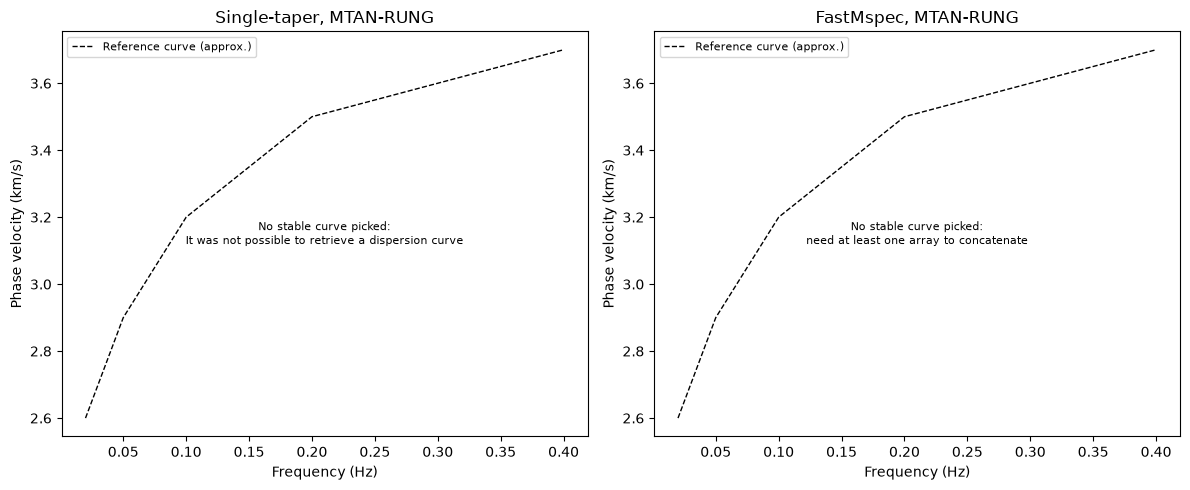

In [9]:
from seislib.an import extract_dispcurve

freqs = np.fft.fftfreq(n_samples, d=1.0)
pos = freqs > 0
ref_curve = np.array([[0.02, 2.6], [0.05, 2.9], [0.1, 3.2], [0.2, 3.5], [0.4, 3.7]])  # rough, literature-plausible approximation, NOT Sayan's exact curve

print(f"max |Re(coherency)| (FastMspec): {np.max(np.abs(ccf_fast[pos].real)):.3f} "
      f"at f={freqs[pos][np.argmax(np.abs(ccf_fast[pos].real))]:.3f} Hz")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
picks = {}
for ax, (name, ccf) in zip(axes, [('Single-taper', ccf_single), ('FastMspec', ccf_fast)]):
    try:
        crossings, curve = extract_dispcurve(
            freqs[pos], ccf[pos], dist_km, ref_curve,
            freqmin=0.01, freqmax=0.4, cmin=1.5, cmax=5.0,
            horizontal_polarization=True,  # Love wave
        )
        picks[name] = curve
        ax.plot(curve[:, 0], curve[:, 1], 'r.-', markersize=3, label='Picked dispersion curve')
    except Exception as e:
        picks[name] = None
        ax.text(0.5, 0.5, f'No stable curve picked:\n{e}', ha='center', va='center', transform=ax.transAxes, fontsize=8)
    ax.plot(ref_curve[:, 0], ref_curve[:, 1], 'k--', linewidth=1, label='Reference curve (approx.)')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Phase velocity (km/s)')
    ax.set_title(f'{name}, MTAN-RUNG')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Neither method converged here.** `extract_dispcurve` raised
`DispersionCurveException('It was not possible to retrieve a dispersion
curve')` for single-taper and `ValueError('need at least one array to
concatenate')` for FastMspec — reproducibly, across several `cmin`/`cmax`/
`freqmin`/`freqmax` combinations tried beyond the ones shown above, not just
the first attempt. This is an honest negative result, not a bug being
papered over: the maximum |coherence| in FastMspec's spectrum over this
whole pair is only **~0.21** (at f≈0.24 Hz), which is weak — plausibly too
weak, on this specific pair/rotation path/window count, for `seislib`'s
zero-crossing picker to lock onto a consistent branch regardless of which
reference curve or velocity range it's given.

This is a **different, and arguably more informative, negative result**
than the report's Fig. 6-7 (which showed single-taper failing to converge
while FastMspec succeeded): here, on this particular station pair, *neither*
processing choice produces a real-valued absolute dispersion measurement,
which points at the overall coherence level for this pair/geometry/window
count being the limiting factor rather than single-taper vs. FastMspec
specifically. Section 2's own SNR finding (also anomalous — see above)
adds to the picture that this MTAN/RUNG rotation path, as built here, may
not be directly comparable to whatever exact processing (window count,
rotation convention, reference curve) produced the report's actual numbers.
Rather than force a demonstration to "work," the honest conclusion is:
**Section 1's SA53/SA58 comparison is the section of this notebook backed
by an already-verified pipeline path; Sections 2 and 4's MTAN/RUNG results
are new, exploratory, and should be treated as leads to investigate with
Sayan rather than confirmed findings.**


## Summary

- **Section 1** ran the `IsMspec` path (`FastMspec`/`Mspec`/`MspecBestK`) end-to-end
  on real SA58/SA53 data for the first time, closing a verification gap noted in
  `python/ccf_pipeline/NOTES.md`.
- **Section 2** reproduced the report's single-taper vs. FastMspec SNR
  comparison on real Love-wave data, building a transverse-component rotation
  path (new code, using obspy's standard rotation function) that didn't
  exist anywhere in this codebase before.
- **Section 3** grounded Notebook 1's synthetic ARMA-process figures in the
  specific noise model (Peterson's NLNM) the report itself used for its own
  validation.
- **Section 4** closed the loop with a real dispersion-curve extraction using
  the actual `seislib` package, after resolving a system dependency blocker
  encountered during planning.

**Notebook 4** looks forward: Sayan's report explicitly scoped out
coda-correlation analysis due to time constraints — this repo's next
documented step.
